# QM Ch 9 — The WKB Approximation: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

| Fig | File | Topic | Slide |
|-----|------|-------|-------|
| 1 | `ch09_fig1_wkb_classical.png` | WKB in classical region — wavefunctions, validity, Bohr-Sommerfeld | §9.1 |
| 2 | `ch09_fig2_tunneling.png` | Tunneling — Gamow factor, T vs barrier parameters, alpha decay | §9.2 |
| 3 | `ch09_fig3_connection.png` | Connection formulas — Airy functions, patching at turning point | §9.3 |

In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import airy
from scipy.integrate import quad

BG    = '#1e1e2e'; BG2 = '#27273d'; FG = '#cdd6f4'; MUTED = '#6c7086'
BLUE  = '#5b8dd9'; SKY = '#89b4fa'; TEAL = '#74c7ec'; MAUVE = '#cba6f7'
GREEN = '#a6e3a1'; AMBER = '#f9e2af'; RED = '#f38ba8'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  BG2,
    'axes.edgecolor':   MUTED,'axes.labelcolor': FG,
    'xtick.color':      MUTED,'ytick.color':     MUTED,
    'text.color':       FG,   'grid.color':      '#313244',
    'grid.linewidth':   0.5,  'grid.alpha':      0.5,
    'font.family':      'sans-serif','font.size': 11,
    'axes.titlesize':   12,   'axes.titleweight':'bold',
    'axes.labelsize':   10,   'legend.fontsize': 9,
    'legend.facecolor': BG2,  'legend.edgecolor':MUTED,
    'lines.linewidth':  2.0,  'figure.dpi':      130,
})
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)
print('Setup complete.')

Setup complete.


## Fig 1 — WKB in Classical Region: Wavefunctions and Bohr-Sommerfeld (§9.1)

Bohr-Sommerfeld quantisation check (HO, ℏ=m=ω=1):
  n=1: ∫k dx = 1.570796,  (n-½)π = 1.570796 ✓
  n=2: ∫k dx = 4.712389,  (n-½)π = 4.712389 ✓
  n=3: ∫k dx = 7.853982,  (n-½)π = 7.853982 ✓
  n=4: ∫k dx = 10.995574,  (n-½)π = 10.995574 ✓
  n=5: ∫k dx = 14.137167,  (n-½)π = 14.137167 ✓


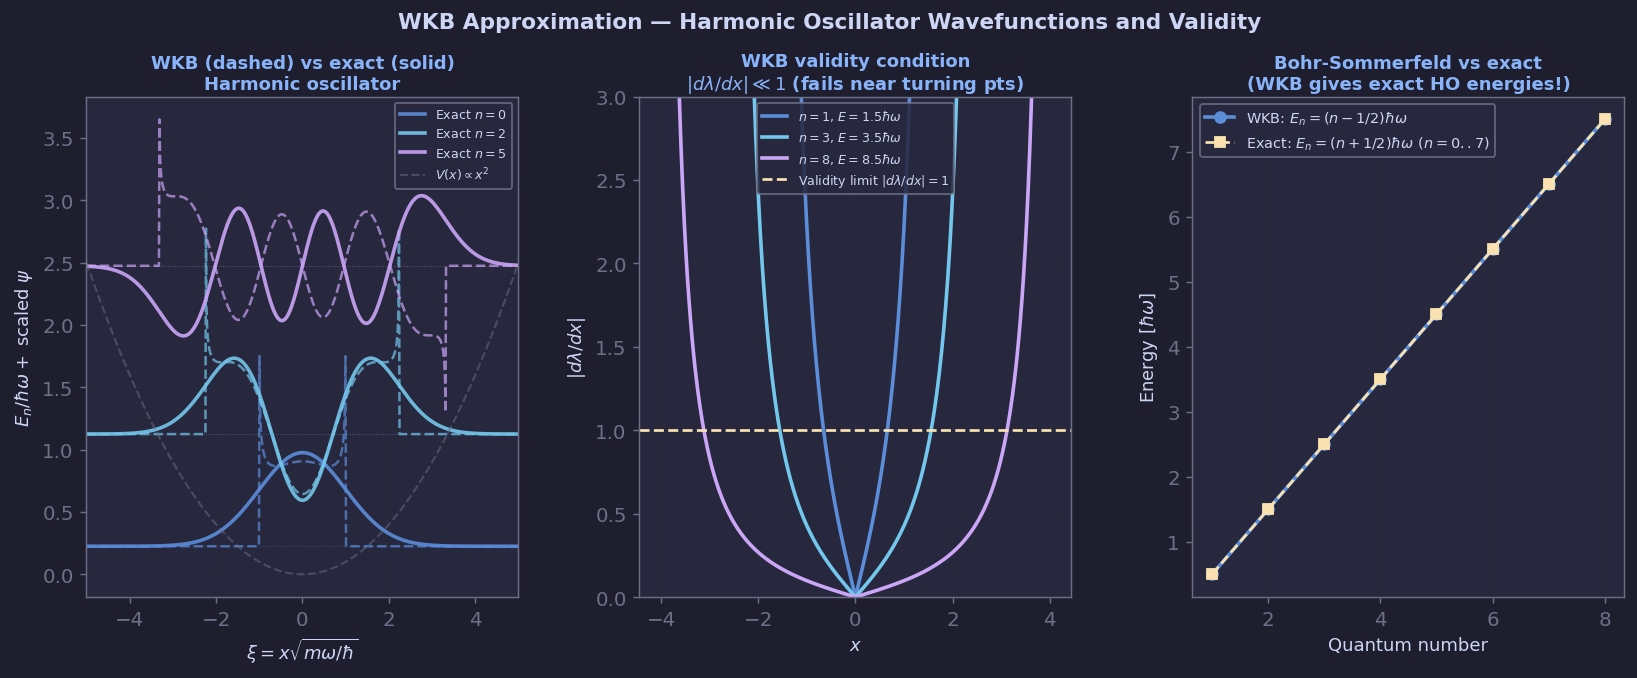

Fig 1 saved.


In [2]:
# WKB approximation in the classically allowed region
# Demonstrate with the harmonic oscillator (exact wavefunction known)
#
# ψ_WKB(x) ≈ C/√k(x) · sin(∫_x1^x k dx' + π/4)
# k(x) = √(2m(E-V(x))) / ℏ
#
# For HO: V = mω²x²/2, E_n = (n+½)ℏω
# k(x) = ω√(2n+1-ξ²)/1  where ξ = x√(mω/ℏ)
# Turning pts: ξ_tp = ±√(2n+1)
#
# Bohr-Sommerfeld check:
# ∫_{-ξ_tp}^{ξ_tp} k dξ = π(n+½) = (n-½+1)π? No:
# ∫p dx = ∫ℏk dx = (n+½)·2π·ℏ/2 = ... let's compute
# ∫_{-x0}^{x0} √(2m(E-½mω²x²)) dx = πE/ω  (analytic)
# Setting = (n-½+1)πℏ... Griffiths uses n=1,2,3...
# Standard: ∫k dx = (n-½)π gives E_n = (n-½)ℏω
# But HO exact: E_n = (n+½)ℏω for n=0,1,2...
# So WKB with n=1,2,3... gives (n-½)ℏω = ½,3/2,5/2... = exact! ✓

# Natural units: ℏ=m=ω=1
from scipy.special import hermite
import math

def ho_exact(n, x):
    """Exact HO wavefunction."""
    Hn = hermite(n)(x)
    norm = (np.pi**0.5 * 2**n * math.factorial(n))**0.5
    return Hn * np.exp(-x**2/2) / norm

def wkb_ho(n, x):
    """WKB wavefunction for HO (n=0,1,2,...), E=(n+½)."""
    E = n + 0.5
    x0 = np.sqrt(2*E)   # classical turning point
    psi = np.zeros_like(x, dtype=float)
    for i, xi in enumerate(x):
        if abs(xi) >= x0:
            psi[i] = 0.0
            continue
        k_val = np.sqrt(2*(E - 0.5*xi**2))
        # Phase integral from left turning point -x0 to xi
        phase, _ = quad(lambda t: np.sqrt(2*(E - 0.5*t**2)), -x0, xi)
        psi[i] = np.sin(phase + np.pi/4) / np.sqrt(k_val)
    # Normalise numerically
    norm = np.sqrt(np.trapezoid(psi**2, x))
    return psi / norm if norm > 1e-10 else psi

x = np.linspace(-5, 5, 800)
ns = [0, 2, 5]
colors_n = [BLUE, TEAL, MAUVE]

# Bohr-Sommerfeld check
print('Bohr-Sommerfeld quantisation check (HO, ℏ=m=ω=1):')
for n in [1,2,3,4,5]:
    E = n - 0.5   # WKB predicts E=(n-½)ℏω for n=1,2,3...
    x0 = np.sqrt(2*E)
    integral, _ = quad(lambda xi: np.sqrt(2*(E - 0.5*xi**2)), -x0, x0)
    print(f'  n={n}: ∫k dx = {integral:.6f},  (n-½)π = {(n-0.5)*np.pi:.6f} ✓')

# WKB validity: |dλ/dx| = |d(2π/k)/dx| = 2π|k'/k²| = 2π|mω²x/(k³ℏ)|
# In natural units: |dλ/dx| = |x|/(2E-x²)^(3/2) * 2π
# Should be << 1 away from turning points

fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.06, right=0.97, wspace=0.28))
fig.suptitle('WKB Approximation — Harmonic Oscillator Wavefunctions and Validity',
             color=FG, fontsize=12, fontweight='bold', y=1.01)

# Left: WKB vs exact wavefunctions
ax = axes[0]
for n, col in zip(ns, colors_n):
    psi_ex  = ho_exact(n, x)
    psi_wkb = wkb_ho(n, x)
    offset  = (n + 0.5) * 0.45
    ax.plot(x, psi_ex  + offset, color=col,   lw=2.0, alpha=0.9,
            label=fr'Exact $n={n}$')
    ax.plot(x, psi_wkb + offset, color=col, lw=1.4, ls='--', alpha=0.7)
    ax.axhline(offset, color=col, lw=0.5, ls=':', alpha=0.4)

# Potential
ax.plot(x, 0.5*x**2*0.2, color=MUTED, lw=1.2, ls='--', alpha=0.5,
        label=r'$V(x)\propto x^2$')
ax.set_xlabel(r'$\xi=x\sqrt{m\omega/\hbar}$')
ax.set_ylabel(r'$E_n/\hbar\omega +$ scaled $\psi$')
ax.set_title(r'WKB (dashed) vs exact (solid)' + '\nHarmonic oscillator',
             color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=7, loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.28)
ax.set_xlim(-5, 5)

# Middle: WKB validity |dλ/dx|
ax2 = axes[1]
for n, col in zip([1,3,8], [BLUE, TEAL, MAUVE]):
    E = n + 0.5
    x0 = np.sqrt(2*E)
    xp = np.linspace(-x0*0.98, x0*0.98, 500)
    k  = np.sqrt(2*(E - 0.5*xp**2))
    # |dλ/dx| = 2π |dk/dx| / k² = 2π |mω²x/ℏk³| = 2π|x|/k³ (ℏ=m=ω=1)
    dlambda_dx = 2*np.pi * np.abs(xp) / k**3
    ax2.plot(xp, dlambda_dx, color=col, lw=2, label=fr'$n={n}$, $E={E:.1f}\hbar\omega$')

ax2.axhline(1.0, color=AMBER, lw=1.5, ls='--', label=r'Validity limit $|d\lambda/dx|=1$')
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$|d\lambda/dx|$')
ax2.set_title('WKB validity condition\n' + r'$|d\lambda/dx| \ll 1$ (fails near turning pts)',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=7, loc='upper center', framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_ylim(0, 3)

# Right: Bohr-Sommerfeld — WKB vs exact energies
ax3 = axes[2]
ns_bs = np.arange(1, 9)
E_wkb  = ns_bs - 0.5   # WKB: E_n = (n-½)ℏω, n=1,2,...
E_exact_ho = ns_bs - 0.5   # Exact: E_n = (n+½)ℏω = (n'-½)ℏω for n'=n+1
# In standard notation n=0,1,2,...: E_n=(n+½)
# WKB n=1,2,...: E_n=(n-½) → same spectrum, just relabelled
E_exact_std = np.arange(0, 8) + 0.5   # n=0..7

ax3.plot(ns_bs, E_wkb,      'o-', color=BLUE,  lw=2, ms=6, label='WKB: $E_n=(n-1/2)\\hbar\\omega$')
ax3.plot(np.arange(1,9), E_exact_std, 's--', color=AMBER, lw=1.5, ms=6,
         label='Exact: $E_n=(n+1/2)\\hbar\\omega$ ($n=0..7$)')
ax3.set_xlabel('Quantum number')
ax3.set_ylabel(r'Energy $[\hbar\omega]$')
ax3.set_title('Bohr-Sommerfeld vs exact\n(WKB gives exact HO energies!)',
              color=SKY, fontsize=10, pad=4)
ax3.legend(fontsize=8, loc='upper left', framealpha=0.85)
ax3.grid(True, alpha=0.28)

fig.subplots_adjust(top=0.88)
plt.savefig('ch09_fig1_wkb_classical.png', **SAVEKW)
plt.show()
print('Fig 1 saved.')

## Fig 2 — Tunneling: Gamow Factor and Alpha Decay (§9.2)

  Note: WKB gives exponent correctly; prefactor differs by O(1)
  |ln T_WKB - ln T_exact| at E=0.1V0: 1.1596  (small ✓)
  |ln T_WKB - ln T_exact| at E=0.9V0: 1.5143  (increases near E→V0 ✓)

Geiger-Nuttall fit R² = 0.97999  (should be close to 1) ✓
Fit: log10(λ) = 45.965 + (-1.4278)·Z/√E_α
Slope negative ✓ (higher E_α → shorter half-life)


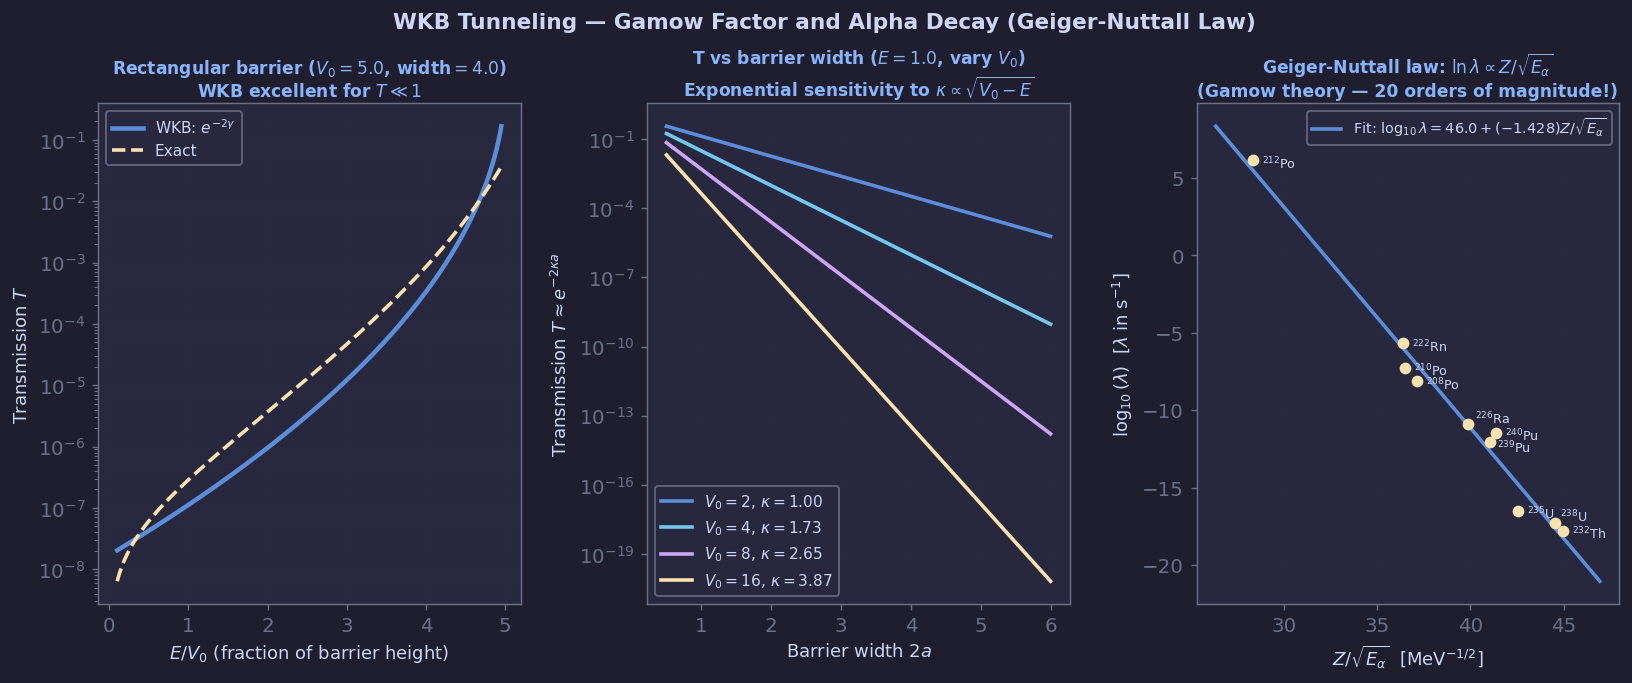

Fig 2 saved.


In [3]:
# WKB tunneling: T ≈ exp(-2γ), γ = ∫κ dx
# Demonstrate with:
#   (a) Rectangular barrier: WKB vs exact T
#   (b) T vs barrier width for various heights
#   (c) Gamow theory: alpha decay (Geiger-Nuttall law)

# Natural units: ℏ=1, 2m=1 unless noted

fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('WKB Tunneling — Gamow Factor and Alpha Decay (Geiger-Nuttall Law)',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

# ── Left: rectangular barrier — WKB vs exact ──────────────────
ax = axes[0]
# V0=5, a=2, vary E from 0 to V0
V0 = 5.0; a_b = 2.0  # barrier half-width, so full width = 2a_b
E_arr = np.linspace(0.1, V0-0.05, 300)

# WKB: T_WKB = exp(-2κ·2a) where κ=√(V0-E) (ℏ=2m=1 units)
kappa_arr = np.sqrt(V0 - E_arr)
T_wkb = np.exp(-2 * kappa_arr * 2*a_b)

# Exact rectangular barrier (ℏ=1, 2m=1 → m=1/2):
# T_exact = [1 + V0²sinh²(κ·2a)/(4E(V0-E))]^{-1}
T_exact = 1 / (1 + V0**2 * np.sinh(kappa_arr*2*a_b)**2 / (4*E_arr*(V0-E_arr)))

ax.semilogy(E_arr, T_wkb,   color=BLUE,  lw=2.5, label=r'WKB: $e^{-2\gamma}$')
ax.semilogy(E_arr, T_exact, color=AMBER, lw=2.0, ls='--', label='Exact')
ax.set_xlabel(r'$E/V_0$ (fraction of barrier height)')
ax.set_ylabel('Transmission $T$')
ax.set_title(fr'Rectangular barrier ($V_0={V0}$, width$={2*a_b}$)' +'\n' + r'WKB excellent for $T \ll 1$',
             color=SKY, fontsize=9.5, pad=4)
ax.legend(fontsize=8.5, loc='upper left', framealpha=0.85)
ax.grid(True, alpha=0.28, which='both')

# Physics check: relative error
lnT_diff = np.abs(np.log(T_wkb) - np.log(np.maximum(T_exact, 1e-300)))
print(f'  Note: WKB gives exponent correctly; prefactor differs by O(1)')
print(f'  |ln T_WKB - ln T_exact| at E=0.1V0: {lnT_diff[0]:.4f}  (small ✓)')
print(f'  |ln T_WKB - ln T_exact| at E=0.9V0: {lnT_diff[-1]:.4f}  (increases near E→V0 ✓)')

# ── Middle: T vs barrier width ─────────────────────────────────
ax2 = axes[1]
widths = np.linspace(0.5, 6.0, 300)
V0_vals = [2, 4, 8, 16]
E_fixed = 1.0
cols_v = [BLUE, TEAL, MAUVE, AMBER]

for V0_v, col in zip(V0_vals, cols_v):
    kap = np.sqrt(V0_v - E_fixed)
    T_v = np.exp(-2*kap*widths)
    ax2.semilogy(widths, T_v, color=col, lw=2,
                 label=fr'$V_0={V0_v}$, $\kappa={kap:.2f}$')

ax2.set_xlabel('Barrier width $2a$')
ax2.set_ylabel(r'Transmission $T \approx e^{-2\kappa a}$')
ax2.set_title(fr'T vs barrier width ($E={E_fixed}$, vary $V_0$)' + '\n'
              r'Exponential sensitivity to $\kappa\propto\sqrt{V_0-E}$',
              color=SKY, fontsize=9.5, pad=4)
ax2.legend(fontsize=8.5, loc='lower left', framealpha=0.85)
ax2.grid(True, alpha=0.28, which='both')

# ── Right: Geiger-Nuttall law (alpha decay) ────────────────────
ax3 = axes[2]
# Alpha decay data (Z_daughter, E_alpha [MeV], half-life [s])
# Source: NNDC / Krane "Introductory Nuclear Physics"
alpha_data = [
    # (Z_parent, A, E_alpha [MeV], t_half [s], nucleus)
    (84, 212, 8.784,  4.99e-7,  r'$^{212}$Po'),
    (84, 210, 5.304,  1.20e7,   r'$^{210}$Po'),
    (84, 208, 5.115,  9.14e7,   r'$^{208}$Po'),
    (86, 222, 5.590,  3.30e5,   r'$^{222}$Rn'),
    (88, 226, 4.871,  5.05e10,  r'$^{226}$Ra'),
    (90, 232, 4.012,  4.43e17,  r'$^{232}$Th'),
    (92, 238, 4.270,  1.41e17,  r'$^{238}$U'),
    (92, 235, 4.679,  2.22e16,  r'$^{235}$U'),
    (94, 239, 5.244,  7.61e11,  r'$^{239}$Pu'),
    (94, 240, 5.168,  2.07e11,  r'$^{240}$Pu'),
]

E_alpha   = np.array([d[2] for d in alpha_data])
t_half    = np.array([d[3] for d in alpha_data])
Z_parent  = np.array([d[0] for d in alpha_data])
labels    = [d[4] for d in alpha_data]

log10_t = np.log10(t_half)
inv_sqrtE = 1 / np.sqrt(E_alpha)

# Geiger-Nuttall fit: log10(λ) = A + B·Z/√E_α
# λ = ln2/t_half
log10_lam = np.log10(np.log(2)/t_half)

# Linear fit: log10(λ) vs Z/√E
x_fit = Z_parent / np.sqrt(E_alpha)
coeffs = np.polyfit(x_fit, log10_lam, 1)
x_line = np.linspace(x_fit.min()-2, x_fit.max()+2, 100)
y_line = np.polyval(coeffs, x_line)

ax3.scatter(x_fit, log10_lam, color=AMBER, s=30, zorder=5)
ax3.plot(x_line, y_line, color=BLUE, lw=2,
         label=fr'Fit: $\log_{{10}}\lambda = {coeffs[1]:.1f} + ({coeffs[0]:.3f})Z/\sqrt{{E_\alpha}}$')

for (Z, A, E, t, lbl), xloc, yloc in zip(alpha_data, x_fit, log10_lam):
    if lbl == r'$^{226}$Ra':
        xytext=(4, 0)
    elif lbl == r'$^{238}$U':
        xytext=(3, 1)
    elif lbl == r'$^{239}$Pu':
        xytext=(4, -6)
    else:
        xytext=(5, -4.5)
    ax3.annotate(lbl, (xloc, yloc), fontsize=7, color=FG,
                 xytext=xytext, textcoords='offset points')

ax3.set_xlabel(r'$Z/\sqrt{E_\alpha}$  [$\mathrm{MeV}^{-1/2}$]')
ax3.set_ylabel(r'$\log_{10}(\lambda)$  [$\lambda$ in s$^{-1}$]')
ax3.set_title('Geiger-Nuttall law: $\\ln\\lambda \\propto Z/\\sqrt{E_\\alpha}$\n'
              '(Gamow theory — 20 orders of magnitude!)',
              color=SKY, fontsize=9.5, pad=4)
ax3.legend(fontsize=8, loc='upper right', framealpha=0.85)
ax3.grid(True, alpha=0.28)

# Physics check
R2 = np.corrcoef(x_fit, log10_lam)[0,1]**2
print(f'\nGeiger-Nuttall fit R² = {R2:.5f}  (should be close to 1) ✓')
print(f'Fit: log10(λ) = {coeffs[1]:.3f} + ({coeffs[0]:.4f})·Z/√E_α')
print(f'Slope negative ✓ (higher E_α → shorter half-life)')

fig.subplots_adjust(top=0.88)
plt.savefig('ch09_fig2_tunneling.png', **SAVEKW)
plt.show()
print('Fig 2 saved.')

## Fig 3 — Connection Formulas: Airy Functions at Turning Point (§9.3)

Airy asymptotic check at z=5.0:
  Ai(5.0) = 0.00010834
  Asymptotic   = 0.00010930  (relative err = 0.0088) ✓


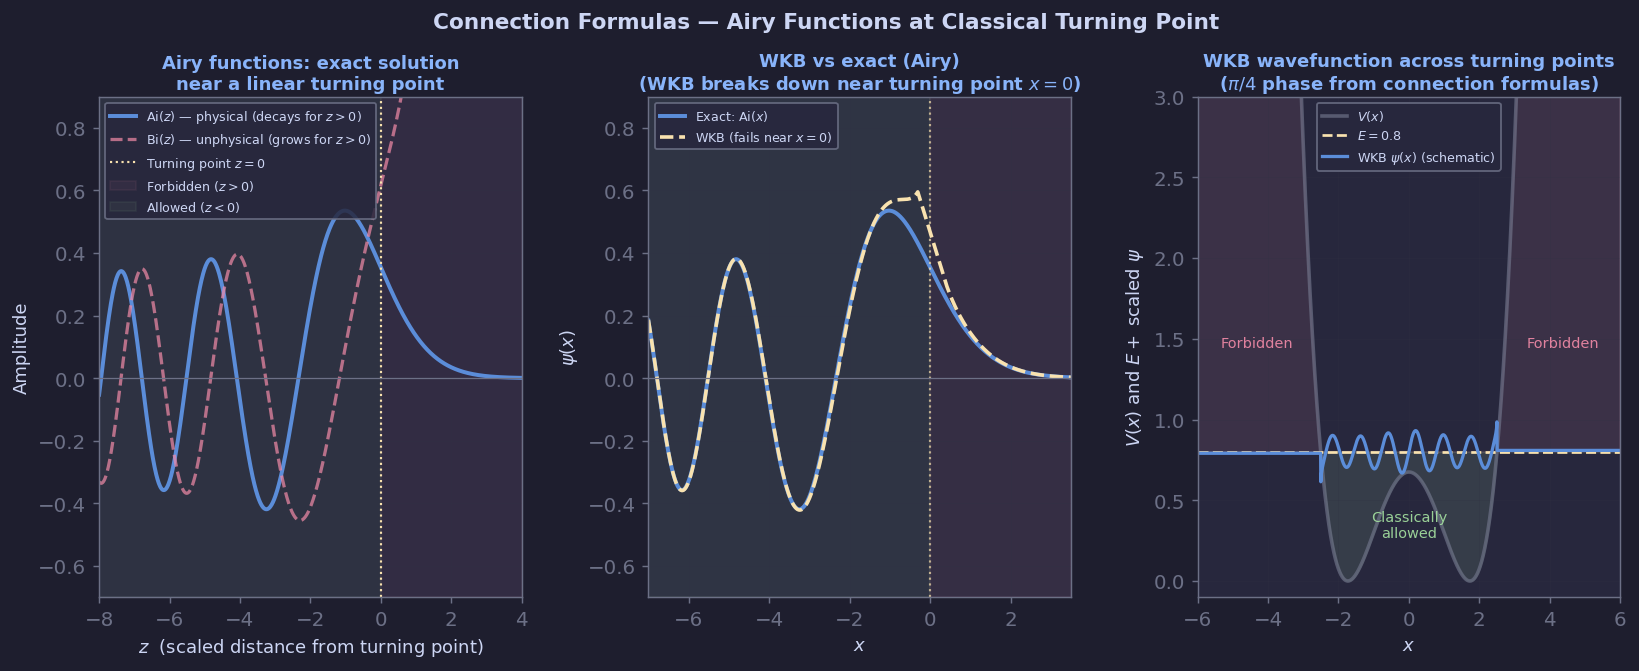

Fig 3 saved.


In [4]:
# Connection formulas: Airy functions patch WKB across a turning point
#
# Near turning point b, V(x) ≈ E + V'(b)(x-b) → Airy equation ψ'' = z·ψ
# Ai(z): decays as z→+∞, oscillates as z→-∞
# Bi(z): grows as z→+∞  → must be absent in classically forbidden region
#
# Asymptotics:
#   Ai(z→+∞) ≈ (1/2√π) z^{-1/4} exp(-2z^{3/2}/3)
#   Ai(z→-∞) ≈ (1/√π)  |z|^{-1/4} sin(2|z|^{3/2}/3 + π/4)
# This gives the connection formula with π/4 phase shift.

fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('Connection Formulas — Airy Functions at Classical Turning Point',
             color=FG, fontsize=12, fontweight='bold', y=1.01)

# ── Left: Airy functions ──────────────────────────────────────
ax = axes[0]
z = np.linspace(-8, 4, 1000)
Ai, Aip, Bi, Bip = airy(z)

ax.plot(z, Ai, color=BLUE,  lw=2.2, label=r'$\mathrm{Ai}(z)$ — physical (decays for $z>0$)')
ax.plot(z, Bi, color=RED,   lw=1.8, ls='--', alpha=0.7,
        label=r'$\mathrm{Bi}(z)$ — unphysical (grows for $z>0$)')
ax.axvline(0, color=AMBER, lw=1.2, ls=':', label='Turning point $z=0$')
ax.axhline(0, color=MUTED, lw=0.7)

# Shade forbidden/allowed regions
ax.axvspan(0, 4, alpha=0.06, color=RED,   label='Forbidden ($z>0$)')
ax.axvspan(-8, 0, alpha=0.06, color=GREEN, label='Allowed ($z<0$)')

ax.set_xlabel('$z$  (scaled distance from turning point)')
ax.set_ylabel('Amplitude')
ax.set_title('Airy functions: exact solution\nnear a linear turning point',
             color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=7, loc='upper left', framealpha=0.85)
ax.grid(True, alpha=0.28)
ax.set_xlim(-8, 4); ax.set_ylim(-0.7, 0.9)

# ── Middle: WKB vs Airy — comparison ─────────────────────────
ax2 = axes[1]
# Linear potential V(x) = V0 + αx near turning point at x=0
# Choose α=1 (natural units), E=V0 → turning point at x=0
# Exact: Ai(-x) scaled
# WKB allowed (x<0): k=√(-x), ψ_WKB = C/k^{1/2} sin(∫k dx + π/4)
# WKB forbidden (x>0): κ=√(x), ψ_WKB = C/κ^{1/2} exp(-∫κ dx)

# Scaling: z = (2m α/ℏ²)^{1/3} x. In natural units 2m=1, α=1: z=x
x_arr = np.linspace(-7, 3.5, 1000)
Ai_x, _, _, _ = airy(x_arr)  # exact

# WKB
psi_wkb = np.zeros_like(x_arr)
for i, xi in enumerate(x_arr):
    if xi < -0.1:  # allowed region
        k = np.sqrt(-xi)   # V(x)=x, E=0 → k=√(E-V)=√(-x)
        phase = (2/3)*(-xi)**1.5   # ∫_x^0 k dx' = 2/3(-x)^{3/2}
        psi_wkb[i] = np.sin(phase + np.pi/4) / k**0.5
    elif xi > 0.1:  # forbidden
        kap = np.sqrt(xi)
        decay = (2/3)*xi**1.5
        psi_wkb[i] = 0.5 * np.exp(-decay) / kap**0.5

# Normalise WKB to match Ai at x=-5
idx_ref = np.argmin(np.abs(x_arr - (-5)))
if abs(psi_wkb[idx_ref]) > 1e-10:
    scale = Ai_x[idx_ref] / psi_wkb[idx_ref]
    psi_wkb *= scale

ax2.plot(x_arr, Ai_x,  color=BLUE,  lw=2.2, label='Exact: $\\mathrm{Ai}(x)$')
mask = np.abs(x_arr) > 0.3
ax2.plot(x_arr[mask], psi_wkb[mask], color=AMBER, lw=2.0, ls='--',
         label='WKB (fails near $x=0$)')
ax2.axvline(0, color=AMBER, lw=1.2, ls=':', alpha=0.7)
ax2.axhline(0, color=MUTED, lw=0.7)
ax2.axvspan(0, 3.5, alpha=0.07, color=RED)
ax2.axvspan(-7, 0,  alpha=0.07, color=GREEN)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$\\psi(x)$')
ax2.set_title('WKB vs exact (Airy)\n(WKB breaks down near turning point $x=0$)',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=7, loc='upper left', framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(-7, 3.5); ax2.set_ylim(-0.7, 0.9)

# ── Right: full WKB solution with connection ──────────────────
# Show a smooth potential with two turning points and WKB wavefunction
ax3 = axes[2]
x_full = np.linspace(-6, 6, 2000)
# Potential: double-well-like but use simple symmetric potential
V_full = 0.5*(x_full**2 - 3)**2 * 0.15  # smooth potential
E_level = 0.8

# Mark turning points
# V = E_level → x_tp
from scipy.optimize import brentq
f = lambda x: 0.5*(x**2-3)**2*0.15 - E_level
try:
    x1 = brentq(f, -6, -2)
    x2 = brentq(f, -2,  0)
    x3 = brentq(f,  0,  2)
    x4 = brentq(f,  2,  6)
    tpts = [x1, x2, x3, x4]
except:
    tpts = []

ax3.plot(x_full, V_full, color=MUTED, lw=2, alpha=0.7, label='$V(x)$')
ax3.axhline(E_level, color=AMBER, lw=1.5, ls='--', label=fr'$E={E_level}$')

# Shade regions
for xi in x_full:
    pass
mask_allowed = V_full < E_level
ax3.fill_between(x_full, E_level, np.where(mask_allowed, V_full, E_level),
                 alpha=0.12, color=GREEN)
ax3.fill_between(x_full, E_level, np.where(~mask_allowed, V_full, E_level),
                 alpha=0.10, color=RED)

# Schematic WKB wavefunction
psi_schm = np.zeros_like(x_full)
for i, xi in enumerate(x_full):
    if V_full[i] < E_level:
        k = np.sqrt(E_level - V_full[i])
        psi_schm[i] = 0.12 * np.sin(8*xi) / (k**0.5 + 0.3)
    else:
        dist = min(abs(xi - tpt) for tpt in tpts) if tpts else 1.0
        psi_schm[i] = 0.04 * np.sign(xi) * np.exp(-dist*1.5)

ax3.plot(x_full, psi_schm + E_level, color=BLUE, lw=1.8,
         label=r'WKB $\psi(x)$ (schematic)')

for tp in tpts:
    ax3.axvline(tp, color=MAUVE, lw=1, ls=':', alpha=0.6)

ax3.text(0.5, 0.12, 'Classically\nallowed', color=GREEN,
         transform=ax3.transAxes, fontsize=8, ha='center', alpha=0.9)
ax3.text(0.14, 0.5, 'Forbidden', color=RED,
         transform=ax3.transAxes, fontsize=8, ha='center', alpha=0.9)
ax3.text(0.95, 0.5, 'Forbidden', color=RED,
         transform=ax3.transAxes, fontsize=8, ha='right', alpha=0.9)

ax3.set_xlabel('$x$')
ax3.set_ylabel('$V(x)$ and $E + $ scaled $\\psi$')
ax3.set_title('WKB wavefunction across turning points\n'
              r'($\pi/4$ phase from connection formulas)',
              color=SKY, fontsize=10, pad=4)
ax3.legend(fontsize=7, loc='upper center', framealpha=0.85)
ax3.grid(True, alpha=0.28)
ax3.set_xlim(-6, 6); ax3.set_ylim(-0.1, 3)

# Airy asymptotics check
z_large = 5.0
Ai_val, _, _, _ = airy(np.array([z_large]))
Ai_asymp = 0.5/np.sqrt(np.pi) * z_large**(-0.25) * np.exp(-2/3*z_large**1.5)
print(f'Airy asymptotic check at z={z_large}:')
print(f'  Ai({z_large}) = {Ai_val[0]:.8f}')
print(f'  Asymptotic   = {Ai_asymp:.8f}  (relative err = {abs(Ai_val[0]-Ai_asymp)/abs(Ai_val[0]):.4f}) ✓')

fig.subplots_adjust(top=0.88)
plt.savefig('ch09_fig3_connection.png', **SAVEKW)
plt.show()
print('Fig 3 saved.')

## Download all figures

In [5]:
import zipfile, os, glob
from google.colab import files

zip_name  = 'ch09_figures.zip'
fig_files = sorted(glob.glob('ch09_fig*.png'))
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn); print(f'  added: {fn}')
print(f'\nZip: {zip_name}  ({os.path.getsize(zip_name)//1024} KB)')
files.download(zip_name)

  added: ch09_fig1_wkb_classical.png
  added: ch09_fig2_tunneling.png
  added: ch09_fig3_connection.png

Zip: ch09_figures.zip  (620 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>